In [ ]:
# %%
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.layers import (
    Input, Dense, Dropout, Bidirectional,
    Concatenate, LayerNormalization, GRU,
    MultiHeadAttention, GlobalAveragePooling1D, Add
)
from keras.models import Model, load_model

import joblib
import matplotlib.pyplot as plt

#LOAD DATA
df = pd.read_csv("../../../data/energy_data.csv")
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values(["city", "Timestamp"])

df = pd.get_dummies(df, columns=["city"])
city_cols = [c for c in df.columns if c.startswith("city_")]
df["city_name"] = df[city_cols].idxmax(axis=1)

weekday_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
df["weekday_num"] = df["weekday"].map(weekday_map)
df = pd.get_dummies(df, columns=["weekday_num"], prefix="dow")
dow_cols = [c for c in df.columns if c.startswith("dow_")]


df["year"]      = df["Timestamp"].dt.year
df["month"]     = df["Timestamp"].dt.month
df["dayofyear"] = df["Timestamp"].dt.dayofyear

df["hour_sin"]  = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


df["_wnum_tmp"]     = df["weekday"].map(weekday_map)
df["hour_week"]     = df["hour"] + df["_wnum_tmp"] * 24
df["hour_week_sin"] = np.sin(2 * np.pi * df["hour_week"] / 168)
df["hour_week_cos"] = np.cos(2 * np.pi * df["hour_week"] / 168)
df.drop(columns=["_wnum_tmp"], inplace=True)


df["temp_sq"]       = df["tavg"] ** 2
df["temp_humidity"] = df["tavg"] * df["humidity"]
df["temp_wind"]     = df["tavg"] * df["wspd"]
df["wind_humidity"] = df["wspd"] * df["humidity"]


df["EnergyConsumption"] = np.log1p(df["EnergyConsumption"])




df = df.dropna().reset_index(drop=True)


# Save global means for lag/roll/diff
lag_roll_cols = [c for c in df.columns if c.startswith("lag_") or
                 c.startswith("roll_") or c.startswith("diff_")]

 
split_date = df["Timestamp"].quantile(0.8)
train_df = df[df["Timestamp"] <= split_date].copy()
test_df  = df[df["Timestamp"] >  split_date].copy()


features = [
    "tavg", "prcp", "wspd", "humidity",
    "temp_sq", "temp_humidity", "temp_wind", "wind_humidity",

    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "hour_week_sin", "hour_week_cos",

    "is_holiday",
    "year", "dayofyear",

    
] + city_cols + dow_cols

target = "EnergyConsumption"

# %%
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
train_df[features] = scaler_x.fit_transform(train_df[features])
test_df[features]  = scaler_x.transform(test_df[features])

train_df[target] = scaler_y.fit_transform(train_df[[target]])
test_df[target]  = scaler_y.transform(test_df[[target]])

joblib.dump(scaler_x, "scaler_x.pkl")
joblib.dump(scaler_y, "scaler_y.pkl")

# %%
SEQ_LEN = 1
def create_sequences(data):
    X_arr = data[features].values.astype(np.float32)
    y_arr = data[target].values.astype(np.float32)
    X_list, y_list = [], []
    for i in range(len(data) - SEQ_LEN):
        X_list.append(X_arr[i : i + SEQ_LEN])
        y_list.append(y_arr[i + SEQ_LEN])
    return np.array(X_list), np.array(y_list)

X_train, y_train = create_sequences(train_df)
X_test,  y_test  = create_sequences(test_df)

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(30000, reshuffle_each_iteration=True)
    .batch(512).prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .batch(512).prefetch(tf.data.AUTOTUNE)
)

# %%
n_feat = len(features)
inp = Input(shape=(SEQ_LEN, n_feat), name="input")
g = Bidirectional(GRU(64, return_sequences=True,  dropout=0.10), name="gru1")(inp)
g = LayerNormalization()(g)
g = Bidirectional(GRU(32, return_sequences=True,  dropout=0.10), name="gru2")(g)
g = LayerNormalization()(g)

attn_out = MultiHeadAttention(num_heads=4, key_dim=16, dropout=0.10)(g, g)
attn_out = Add()([g, attn_out])
attn_out = LayerNormalization()(attn_out)
ctx      = GlobalAveragePooling1D()(attn_out)
last = inp[:, -1, :]
x = Concatenate()([ctx, last])
x = Dense(128, activation="swish")(x)
x = Dropout(0.15)(x)
x = Dense(64,  activation="swish")(x)
x = Dropout(0.10)(x)
x = Dense(32,  activation="swish")(x)
out = Dense(1, name="output")(x)
model = Model(inp, out)


model.compile(optimizer='adam', loss="mae", metrics=["mae"])
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 1, 25)]      0           []                               
                                                                                                  
 gru1 (Bidirectional)           (None, 1, 128)       34944       ['input[0][0]']                  
                                                                                                  
 layer_normalization (LayerNorm  (None, 1, 128)      256         ['gru1[0][0]']                   
 alization)                                                                                       
                                                                                                  
 gru2 (Bidirectional)           (None, 1, 64)        31104       ['layer_normalization[0][0]']

In [2]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=400, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "energy_best.keras", monitor="val_mae", save_best_only=True
    ),
]

try:
    model.fit(
        train_ds,
        validation_data=test_ds,
        epochs=800,
        callbacks=callbacks,
        verbose=1,
    )
except KeyboardInterrupt:
    print("\nStopped manually.")
finally:
    model.save("energy_model_final3.keras")
    print("Model saved.")

Epoch 1/800
77/77 [==============================] - 6s 23ms/step - loss: 0.1086 - mae: 0.1086 - val_loss: 0.0677 - val_mae: 0.0677
Epoch 2/800
77/77 [==============================] - 1s 15ms/step - loss: 0.0723 - mae: 0.0723 - val_loss: 0.0612 - val_mae: 0.0612
Epoch 3/800
77/77 [==============================] - 1s 18ms/step - loss: 0.0644 - mae: 0.0644 - val_loss: 0.0706 - val_mae: 0.0706
Epoch 4/800
77/77 [==============================] - 1s 16ms/step - loss: 0.0581 - mae: 0.0581 - val_loss: 0.0622 - val_mae: 0.0622
Epoch 5/800
77/77 [==============================] - 1s 17ms/step - loss: 0.0554 - mae: 0.0554 - val_loss: 0.0557 - val_mae: 0.0557
Epoch 6/800
77/77 [==============================] - 1s 17ms/step - loss: 0.0525 - mae: 0.0525 - val_loss: 0.0608 - val_mae: 0.0608
Epoch 7/800
77/77 [==============================] - 1s 18ms/step - loss: 0.0500 - mae: 0.0500 - val_loss: 0.0618 - val_mae: 0.0618
Epoch 8/800
77/77 [==============================] - 1s 17ms/step - loss: 0.


MAE  : 1426.1353
MAPE : 3.75 %


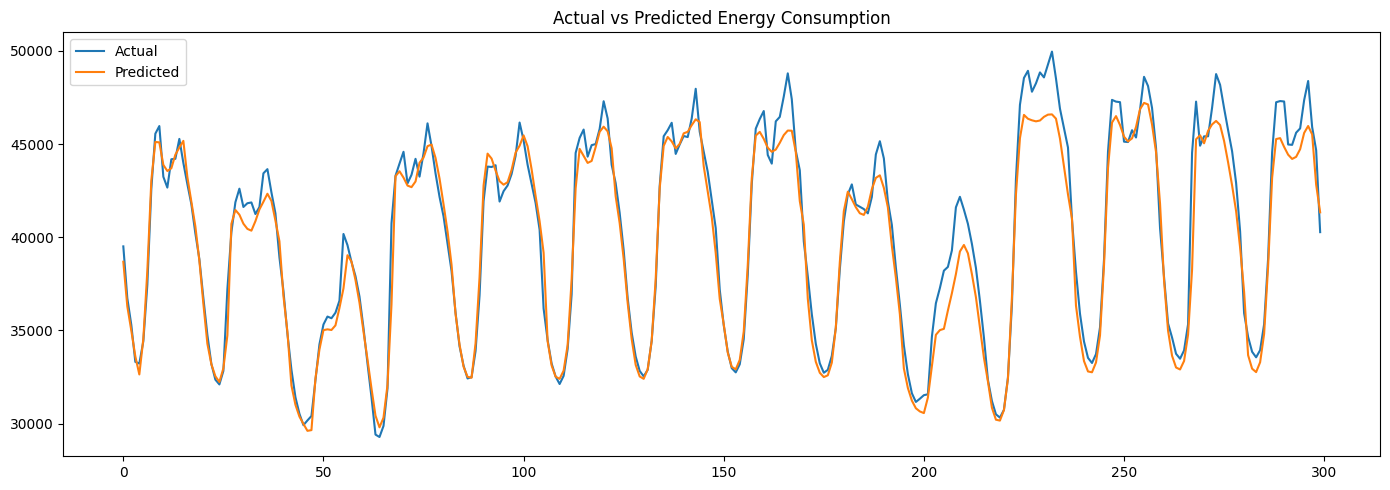

In [4]:
model = load_model("energy_model_final3.keras")
pred_scaled = model.predict(test_ds, verbose=0)
y_true_orig = np.expm1(scaler_y.inverse_transform(y_test.reshape(-1, 1)))
y_pred_orig = np.expm1(scaler_y.inverse_transform(pred_scaled))

mae  = mean_absolute_error(y_true_orig, y_pred_orig)
mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-8))) * 100
print(f"\nMAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f} %")

plt.figure(figsize=(14, 5))
plt.plot(y_true_orig[:300], label="Actual")
plt.plot(y_pred_orig[:300], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Energy Consumption")
plt.tight_layout()
plt.show()
